In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/arunasivapragasam/donors-choose/Preprocessed_DonorsChoose_dataset.csv


Dataset shape: (109248, 4)
  project_is_approved                                   cleaned_titles  \
0                   0        educational support english learners home   
1                   1                 wanted projector hungry learners   
2                   0  soccer equipment awesome middle school students   

                                      cleaned_essays  \
0  students english learners working english seco...   
1  students arrive school eager learn polite gene...   
2  true champions not always ones win guts mia ha...   

                                     cleaned_summary  
0  students_need_opportunities_practice_beginning...  
1  students_need_projector_help_viewing_education...  
2  students_need_shine_guards_athletic_socks_socc...  

Missing values per column:
project_is_approved    0
cleaned_titles         0
cleaned_essays         0
cleaned_summary        0
dtype: int64

Binary target distribution:
funded_binary
1    0.848583
0    0.151417
Name: proportion, d

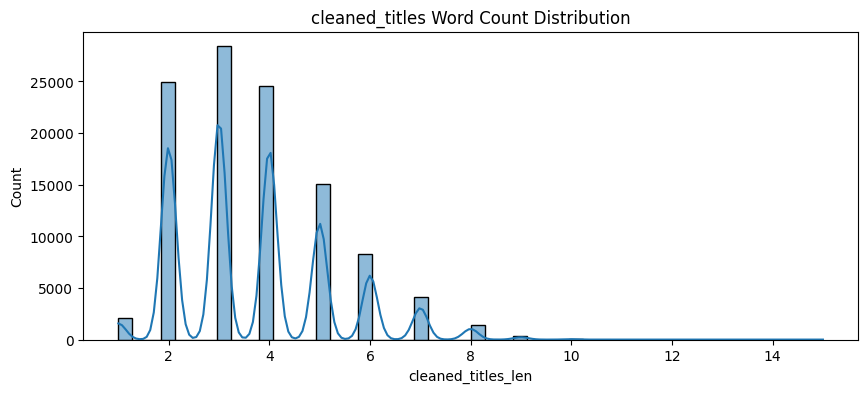

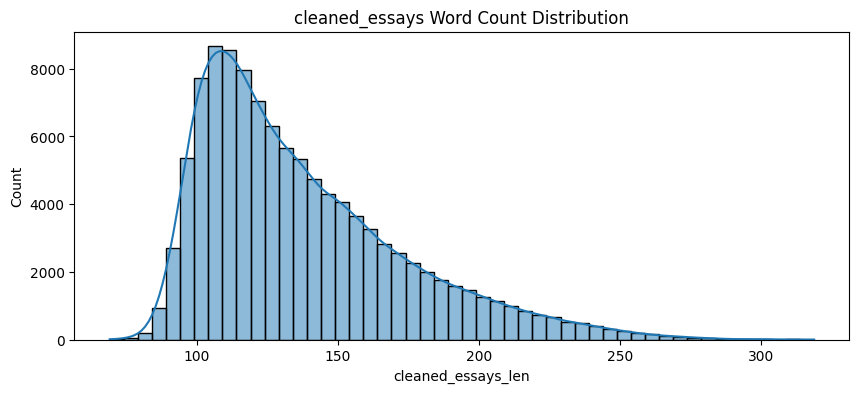

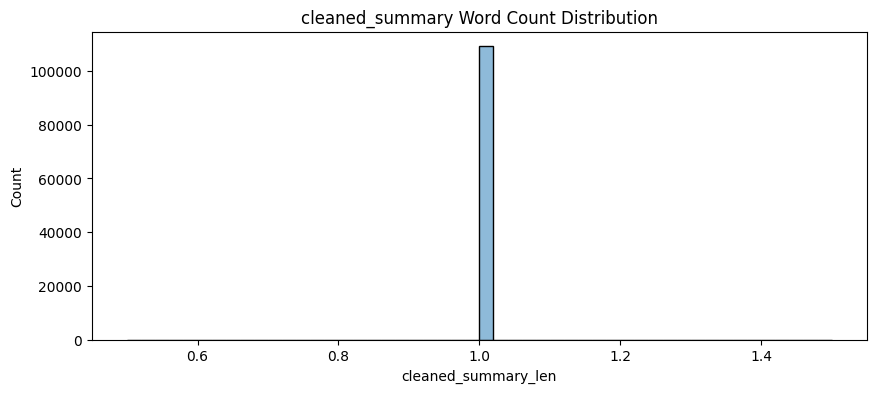


Text length statistics:
       cleaned_titles_len  cleaned_essays_len  cleaned_summary_len
count       109248.000000       109248.000000             109248.0
mean             3.695226          137.184186                  1.0
std              1.524876           36.314227                  0.0
min              1.000000           69.000000                  1.0
25%              3.000000          109.000000                  1.0
50%              3.000000          128.000000                  1.0
75%              5.000000          157.000000                  1.0
max             15.000000          319.000000                  1.0


In [2]:
# --- Prompt 1: Data Exploration & Preparation (Fixed for this dataset) ---

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

csv_path = '/kaggle/input/datasets/arunasivapragasam/donors-choose/Preprocessed_DonorsChoose_dataset.csv'

# Load only text and target columns
text_cols = ['cleaned_titles', 'cleaned_essays', 'cleaned_summary']
target_col = 'project_is_approved'  # Use approval as target

use_cols = text_cols + [target_col]
df = pd.read_csv(csv_path, usecols=use_cols, dtype=str)

# Convert text to string
for col in text_cols:
    df[col] = df[col].astype(str)

# Preview
print("Dataset shape:", df.shape)
print(df.head(3))

# Check missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Convert target to binary
df['funded_binary'] = df[target_col].apply(lambda x: 1 if str(x) == '1' else 0)
print("\nBinary target distribution:")
print(df['funded_binary'].value_counts(normalize=True))

# Explore text lengths
for col in text_cols:
    df[col+'_len'] = df[col].apply(lambda x: len(x.split()))
    plt.figure(figsize=(10,4))
    sns.histplot(df[col+'_len'], bins=50, kde=True).set(title=f'{col} Word Count Distribution')
    plt.show()

# Quick text length stats
len_cols = [col+'_len' for col in text_cols]
print("\nText length statistics:")
print(df[len_cols].describe())

In [3]:
# --- Prompt 2: NLP Preprocessing Pipeline ---

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tqdm import tqdm

# Download NLTK resources if not already
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

# Combine text columns for NLP processing
df['combined_text'] = df['cleaned_titles'] + ' ' + df['cleaned_summary'] + ' ' + df['cleaned_essays']

# Optional: basic cleaning (already cleaned, but just in case)
def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove numbers, punctuation, special characters
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Collapse multiple spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['combined_text'] = df['combined_text'].apply(clean_text)

# Tokenization + stopword removal + lemmatization
def tokenize_lemmatize(text):
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(tok) for tok in tokens if tok not in stop_words]
    return tokens

tqdm.pandas(desc="Tokenizing and lemmatizing")
df['tokens'] = df['combined_text'].progress_apply(tokenize_lemmatize)

# Preview
print(df[['combined_text', 'tokens']].head(3))

# Optional: remove low-frequency words (appearing < 3 documents)
from collections import Counter

# Flatten all tokens
all_tokens = [tok for sublist in df['tokens'] for tok in sublist]
token_counts = Counter(all_tokens)

# Keep tokens with frequency >= 3
vocab = set([tok for tok, count in token_counts.items() if count >= 3])
print(f"Vocabulary size after low-frequency filtering: {len(vocab)}")

# Filter tokens
df['tokens'] = df['tokens'].apply(lambda toks: [tok for tok in toks if tok in vocab])

# Optional: create final cleaned string for TF-IDF
df['final_text'] = df['tokens'].apply(lambda toks: ' '.join(toks))

print("\nSample final_text:")
print(df['final_text'].head(3))

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
Tokenizing and lemmatizing: 100%|██████████| 109248/109248 [01:52<00:00, 970.24it/s] 


                                       combined_text  \
0  educational support english learners home stud...   
1  wanted projector hungry learners students need...   
2  soccer equipment awesome middle school student...   

                                              tokens  
0  [educational, support, english, learner, home,...  
1  [wanted, projector, hungry, learner, student, ...  
2  [soccer, equipment, awesome, middle, school, s...  
Vocabulary size after low-frequency filtering: 26151

Sample final_text:
0    educational support english learner home stude...
1    wanted projector hungry learner student need p...
2    soccer equipment awesome middle school student...
Name: final_text, dtype: object


In [4]:
# --- Prompt 3: Embedding Approaches ---

from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import gensim.downloader as api
from tqdm import tqdm

# ----------------------------
# 1. TF-IDF Vectorization
# ----------------------------

# Memory-efficient: limit max_features
tfidf_vectorizer = TfidfVectorizer(
    max_features=50000,   # adjust depending on memory
    ngram_range=(1,3),    # uni-, bi-, tri-grams
    lowercase=False       # already lowercased
)

# Fit & transform
X_tfidf = tfidf_vectorizer.fit_transform(df['final_text'])
print("TF-IDF shape:", X_tfidf.shape)

# ----------------------------
# 2. Pre-trained Word2Vec
# ----------------------------

# Load Google News vectors (~300d)
print("Loading pre-trained Word2Vec (Google News, 300d)...")
word2vec_model = api.load("word2vec-google-news-300")

embedding_dim = 300

# Function to get averaged embedding per document
def document_vector(tokens):
    vecs = []
    for tok in tokens:
        if tok in word2vec_model.key_to_index:
            vecs.append(word2vec_model[tok])
    if len(vecs) == 0:
        return np.zeros(embedding_dim)
    return np.mean(vecs, axis=0)

# Compute document embeddings
tqdm.pandas(desc="Computing Word2Vec embeddings")
df['w2v_vector'] = df['tokens'].progress_apply(document_vector)

# Convert list of arrays to single 2D numpy array
X_w2v = np.vstack(df['w2v_vector'].values)
print("Word2Vec embedding shape:", X_w2v.shape)

# ----------------------------
# Optional: TF-IDF weighted Word2Vec
# ----------------------------

# Create dict mapping word -> tf-idf weight
tfidf_vocab = tfidf_vectorizer.vocabulary_  # word -> index
tfidf_idf = tfidf_vectorizer.idf_           # idf array
word2idf = {word: tfidf_idf[idx] for word, idx in tfidf_vocab.items()}

def weighted_doc_vector(tokens):
    vecs, weights = [], []
    for tok in tokens:
        if tok in word2vec_model.key_to_index and tok in word2idf:
            vecs.append(word2vec_model[tok])
            weights.append(word2idf[tok])
    if len(vecs) == 0:
        return np.zeros(embedding_dim)
    vecs = np.array(vecs)
    weights = np.array(weights).reshape(-1,1)
    return np.mean(vecs * weights, axis=0)

tqdm.pandas(desc="Computing weighted Word2Vec embeddings")
df['w2v_weighted'] = df['tokens'].progress_apply(weighted_doc_vector)
X_w2v_weighted = np.vstack(df['w2v_weighted'].values)
print("Weighted Word2Vec shape:", X_w2v_weighted.shape)

TF-IDF shape: (109248, 50000)
Loading pre-trained Word2Vec (Google News, 300d)...
[==================================================] 100.0% 1662.8/1662.8MB downloaded


Computing Word2Vec embeddings: 100%|██████████| 109248/109248 [00:24<00:00, 4459.05it/s]


Word2Vec embedding shape: (109248, 300)


Computing weighted Word2Vec embeddings: 100%|██████████| 109248/109248 [00:38<00:00, 2870.52it/s]


Weighted Word2Vec shape: (109248, 300)


In [5]:
# --- Prompt 4: Classical ML Models ---

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Target
y = df['funded_binary'].values

# Train-test split
X_train_tfidf, X_test_tfidf, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)
X_train_w2v, X_test_w2v = train_test_split(X_w2v, test_size=0.2, random_state=42, stratify=y)

print("Train shapes:", X_train_tfidf.shape, X_train_w2v.shape)
print("Test shapes:", X_test_tfidf.shape, X_test_w2v.shape)

# ----------------------------
# 1. Logistic Regression (TF-IDF)
# ----------------------------
print("\nTraining Logistic Regression on TF-IDF...")
lr_tfidf = LogisticRegression(max_iter=500, n_jobs=-1)
lr_tfidf.fit(X_train_tfidf, y_train)
y_pred_lr = lr_tfidf.predict(X_test_tfidf)

print("\nLogistic Regression (TF-IDF) Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1-score:", f1_score(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

# ----------------------------
# 2. Random Forest (Word2Vec)
# ----------------------------
print("\nTraining Random Forest on Word2Vec...")
rf_w2v = RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)
rf_w2v.fit(X_train_w2v, y_train)
y_pred_rf = rf_w2v.predict(X_test_w2v)

print("\nRandom Forest (Word2Vec) Metrics:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# ----------------------------
# Optional: Cross-validation (Logistic Regression TF-IDF)
# ----------------------------
print("\n5-Fold Cross-Validation Accuracy (Logistic Regression TF-IDF):")
cv_scores = cross_val_score(lr_tfidf, X_tfidf, y, cv=5, scoring='accuracy', n_jobs=-1)
print(cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

Train shapes: (87398, 50000) (87398, 300)
Test shapes: (21850, 50000) (21850, 300)

Training Logistic Regression on TF-IDF...

Logistic Regression (TF-IDF) Metrics:
Accuracy: 0.8507093821510298
Precision: 0.8543270568592894
Recall: 0.9934742746197821
F1-score: 0.9186614801516059

Confusion Matrix:
 [[  167  3141]
 [  121 18421]]

Classification Report:
               precision    recall  f1-score   support

           0       0.58      0.05      0.09      3308
           1       0.85      0.99      0.92     18542

    accuracy                           0.85     21850
   macro avg       0.72      0.52      0.51     21850
weighted avg       0.81      0.85      0.79     21850


Training Random Forest on Word2Vec...

Random Forest (Word2Vec) Metrics:
Accuracy: 0.8481006864988558
Precision: 0.8486875257684732
Recall: 0.9991370941645993
F1-score: 0.9177875207450893

Confusion Matrix:
 [[    5  3303]
 [   16 18526]]

Classification Report:
               precision    recall  f1-score   suppor

In [6]:
# --- Prompt 5: Memory-efficient DL model (Functional API) ---
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split

# ----------------------------
# 1. Reduce TF-IDF dimensions with TruncatedSVD (sparse safe)
# ----------------------------
print("Reducing TF-IDF dimensions with TruncatedSVD...")
svd = TruncatedSVD(n_components=5000, random_state=42)
X_tfidf_reduced = svd.fit_transform(X_tfidf)  # <-- no .toarray() here
print("Reduced TF-IDF shape:", X_tfidf_reduced.shape)

# ----------------------------
# 2. Input shapes
# ----------------------------
tfidf_dim = X_tfidf_reduced.shape[1]  # 5000
w2v_dim = X_w2v.shape[1]              # 300

# ----------------------------
# 3. Define Inputs
# ----------------------------
input_tfidf = Input(shape=(tfidf_dim,), name='tfidf_input')
input_w2v = Input(shape=(w2v_dim,), name='w2v_input')

# ----------------------------
# 4. TF-IDF subnetwork
# ----------------------------
x1 = Dense(256, activation='relu')(input_tfidf)
x1 = Dropout(0.3)(x1)
x1 = BatchNormalization()(x1)
x1 = Dense(128, activation='relu')(x1)

# ----------------------------
# 5. Word2Vec subnetwork
# ----------------------------
x2 = Dense(128, activation='relu')(input_w2v)
x2 = Dropout(0.3)(x2)
x2 = BatchNormalization()(x2)
x2 = Dense(64, activation='relu')(x2)

# ----------------------------
# 6. Concatenate subnetworks
# ----------------------------
merged = Concatenate()([x1, x2])
merged = Dense(64, activation='relu')(merged)
merged = Dropout(0.3)(merged)
merged = BatchNormalization()(merged)

# Output layer
output = Dense(1, activation='sigmoid')(merged)

# ----------------------------
# 7. Build model
# ----------------------------
model = Model(inputs=[input_tfidf, input_w2v], outputs=output)
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model.summary()

# ----------------------------
# 8. Train-test split
# ----------------------------
X_train_tfidf_dl, X_val_tfidf, X_train_w2v_dl, X_val_w2v, y_train_dl, y_val = train_test_split(
    X_tfidf_reduced, X_w2v, y, test_size=0.2, random_state=42, stratify=y
)

# ----------------------------
# 9. Model training
# ----------------------------
history = model.fit(
    [X_train_tfidf_dl, X_train_w2v_dl],
    y_train_dl,
    validation_data=([X_val_tfidf, X_val_w2v], y_val),
    epochs=15,
    batch_size=64,   # safe for T4x2
    verbose=1
)

# ----------------------------
# 10. Evaluation
# ----------------------------
y_pred_prob = model.predict([X_val_tfidf, X_val_w2v])
y_pred = (y_pred_prob > 0.5).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("\nDeep Learning Model Metrics:")
print("Accuracy:", accuracy_score(y_val, y_pred))
print("Precision:", precision_score(y_val, y_pred))
print("Recall:", recall_score(y_val, y_pred))
print("F1-score:", f1_score(y_val, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_val, y_pred))
print("\nClassification Report:\n", classification_report(y_val, y_pred))

2026-03-03 18:57:33.990524: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772564254.197284      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772564254.257128      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772564254.740659      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772564254.740701      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772564254.740708      24 computation_placer.cc:177] computation placer alr

Reducing TF-IDF dimensions with TruncatedSVD...
Reduced TF-IDF shape: (109248, 5000)


I0000 00:00:1772565941.261987      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772565941.267945      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tfidf_input         │ (None, 5000)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ w2v_input           │ (None, 300)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │  1,280,256 │ tfidf_input[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │     38,528 │ w2v_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dropout[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dropout_1[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 192)       │          0 │ dense_1[0][0],    │
│ (Concatenate)       │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │     12,352 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dropout_2[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ batch_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

...

Epoch 1/15


I0000 00:00:1772565952.084792     139 service.cc:152] XLA service 0x7c9bd800b3d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772565952.084824     139 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772565952.084830     139 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772565952.726648     139 cuda_dnn.cc:529] Loaded cuDNN version 91002


  45/1366 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.5398 - loss: 0.8206 - precision: 0.8509 - recall: 0.5556

I0000 00:00:1772565955.660058     139 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1366/1366 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.7681 - loss: 0.5099 - precision: 0.8549 - recall: 0.8759 - val_accuracy: 0.8503 - val_loss: 0.3827 - val_precision: 0.8537 - val_recall: 0.9940
Epoch 2/15
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8566 - loss: 0.3583 - precision: 0.8667 - recall: 0.9823 - val_accuracy: 0.8481 - val_loss: 0.3870 - val_precision: 0.8641 - val_recall: 0.9742
Epoch 3/15
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8795 - loss: 0.2911 - precision: 0.8954 - recall: 0.9714 - val_accuracy: 0.8438 - val_loss: 0.4195 - val_precision: 0.8588 - val_recall: 0.9765
Epoch 4/15
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9315 - loss: 0.1765 - precision: 0.9483 - recall: 0.9724 - val_accuracy: 0.8345 - val_loss: 0.5367 - val_precision: 0.8622 - val_recall: 0.9581
Epoch 5/15
1366/1366 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9563 - loss: 0.1192 - precision: 0.9700 - recall: 0.9789 - val_accuracy: 0.8218 - val_loss: 0.

683/683 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


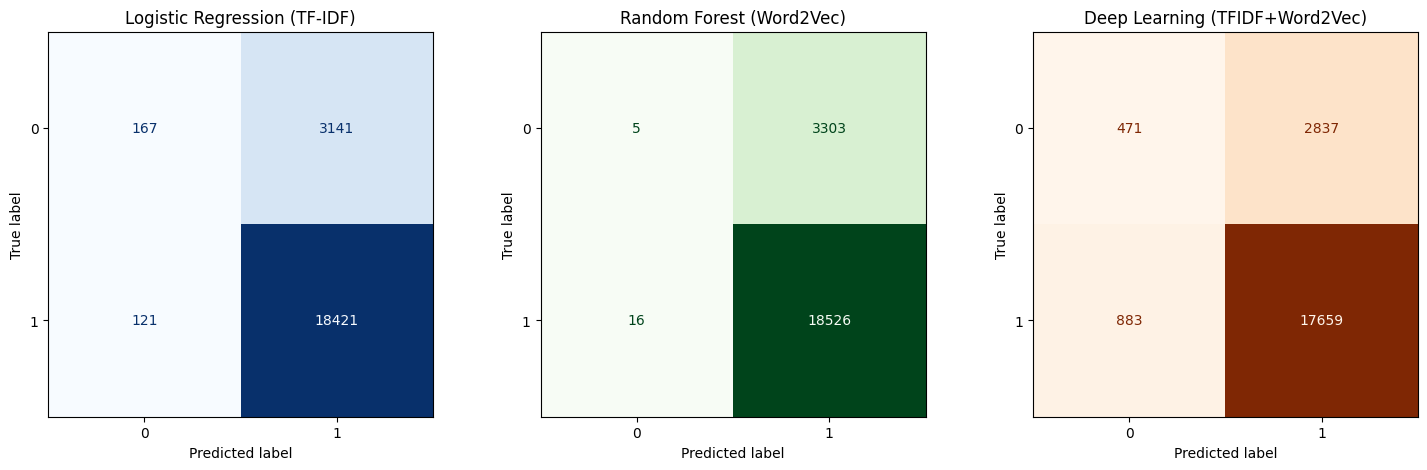

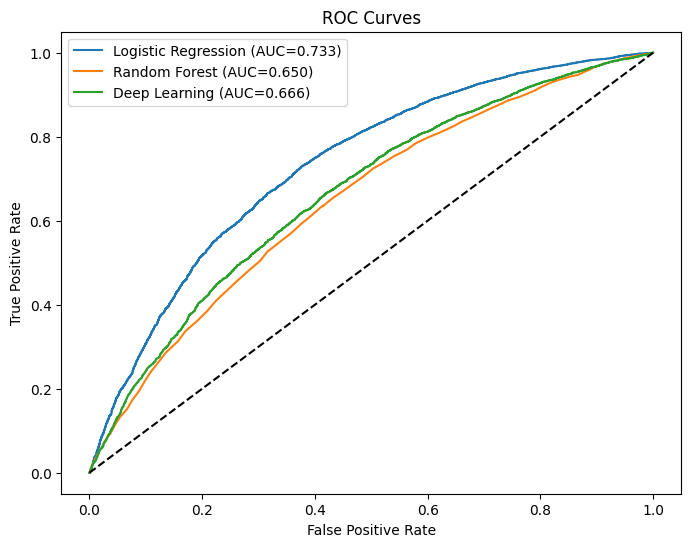

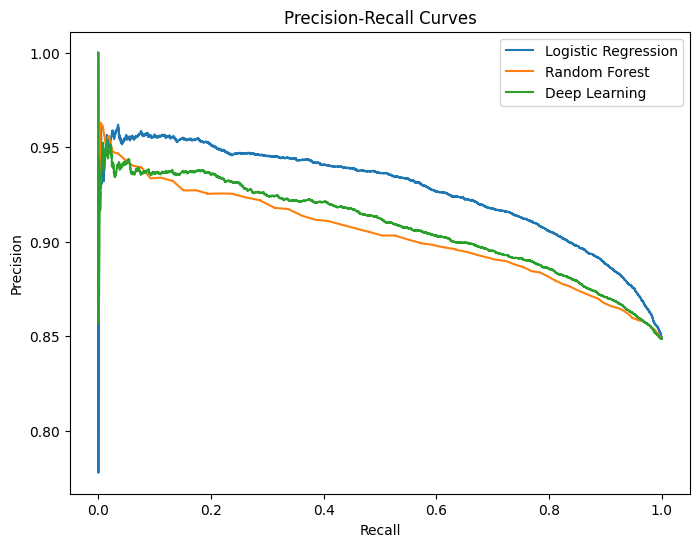

--- Logistic Regression (TF-IDF) ---
Accuracy : 0.8507093821510298
Precision: 0.8543270568592894
Recall   : 0.9934742746197821
F1-score : 0.9186614801516059

--- Random Forest (Word2Vec) ---
Accuracy : 0.8481006864988558
Precision: 0.8486875257684732
Recall   : 0.9991370941645993
F1-score : 0.9177875207450893

--- Deep Learning (TF-IDF+Word2Vec) ---
Accuracy : 0.8297482837528604
Precision: 0.8615827478532396
Recall   : 0.9523783842088233
F1-score : 0.9047082330037399



In [7]:
# --- Prompt 6: Model Comparison & Analysis ---

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# ----------------------------
# 1. Collect predictions
# ----------------------------

# Classical ML
y_pred_lr_prob = lr_tfidf.predict_proba(X_test_tfidf)[:, 1]  # Logistic Regression
y_pred_rf_prob = rf_w2v.predict_proba(X_test_w2v)[:, 1]      # Random Forest

# Deep Learning
y_pred_dl_prob = model.predict([X_val_tfidf, X_val_w2v]).ravel()

# Convert to binary
y_pred_lr_bin = (y_pred_lr_prob > 0.5).astype(int)
y_pred_rf_bin = (y_pred_rf_prob > 0.5).astype(int)
y_pred_dl_bin = (y_pred_dl_prob > 0.5).astype(int)

# ----------------------------
# 2. Confusion Matrices
# ----------------------------
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18,5))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr_bin, ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("Logistic Regression (TF-IDF)")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf_bin, ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title("Random Forest (Word2Vec)")

ConfusionMatrixDisplay.from_predictions(y_val, y_pred_dl_bin, ax=axes[2], cmap='Oranges', colorbar=False)
axes[2].set_title("Deep Learning (TFIDF+Word2Vec)")

plt.show()

# ----------------------------
# 3. ROC Curves
# ----------------------------
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_pred_lr_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_rf_prob)
fpr_dl, tpr_dl, _ = roc_curve(y_val, y_pred_dl_prob)

roc_auc_lr = auc(fpr_lr, tpr_lr)
roc_auc_rf = auc(fpr_rf, tpr_rf)
roc_auc_dl = auc(fpr_dl, tpr_dl)

plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={roc_auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={roc_auc_rf:.3f})')
plt.plot(fpr_dl, tpr_dl, label=f'Deep Learning (AUC={roc_auc_dl:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

# ----------------------------
# 4. Precision-Recall Curves
# ----------------------------
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_pred_lr_prob)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_pred_rf_prob)
prec_dl, rec_dl, _ = precision_recall_curve(y_val, y_pred_dl_prob)

plt.figure(figsize=(8,6))
plt.plot(rec_lr, prec_lr, label='Logistic Regression')
plt.plot(rec_rf, prec_rf, label='Random Forest')
plt.plot(rec_dl, prec_dl, label='Deep Learning')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.show()

# ----------------------------
# 5. Summary Metrics
# ----------------------------
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def summary_metrics(y_true, y_pred, model_name):
    print(f"--- {model_name} ---")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1-score :", f1_score(y_true, y_pred))
    print()

summary_metrics(y_test, y_pred_lr_bin, "Logistic Regression (TF-IDF)")
summary_metrics(y_test, y_pred_rf_bin, "Random Forest (Word2Vec)")
summary_metrics(y_val, y_pred_dl_bin, "Deep Learning (TF-IDF+Word2Vec)")